In [1]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr
import scipy

import regionmask

# import regionmask

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates

import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

In [2]:
rigid_earth_itsg = xr.open_dataset(r'Rigd_Earth_EWH_trend_itsg300GF_ohne_love0.5ohneGIA.nc')
rigid_earth_itsg

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
Data variables:
    tws      (lat, lon) float32 1MB ...
Attributes:
    description:  Global gridded TWS Anomaly trend map(2D)
    units:        mm we/yr

In [3]:
rigid_earth_trend_itsg = rigid_earth_itsg.rename_vars({'tws': 'tws_trend'})
rigid_earth_trend_itsg

<xarray.Dataset> Size: 1MB
Dimensions:    (lat: 360, lon: 720)
Coordinates:
  * lat        (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * lon        (lon) float64 6kB -180.0 -179.5 -179.0 ... 178.5 179.0 179.5
Data variables:
    tws_trend  (lat, lon) float32 1MB ...
Attributes:
    description:  Global gridded TWS Anomaly trend map(2D)
    units:        mm we/yr

In [4]:
rigid_earth_trend_itsg.to_netcdf(r'rigid_earth_trend_itsg_EWH.nc')

-------

In [5]:
EWH_trend_vlm = xr.open_dataset(r'observed_VLM_trend _05deg_full_grids_resampled1.nc')
EWH_trend_vlm

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 360, lon: 720)
Coordinates:
  * lon        (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat        (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
Data variables:
    tws_trend  (lat, lon) float64 2MB ...

In [6]:
EWH_trend_rigid_earth_itsg = xr.open_dataset(r'rigid_earth_trend_itsg_EWH.nc')
EWH_trend_rigid_earth_itsg

<xarray.Dataset> Size: 1MB
Dimensions:    (lat: 360, lon: 720)
Coordinates:
  * lat        (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * lon        (lon) float64 6kB -180.0 -179.5 -179.0 ... 178.5 179.0 179.5
Data variables:
    tws_trend  (lat, lon) float32 1MB ...
Attributes:
    description:  Global gridded TWS Anomaly trend map(2D)
    units:        mm we/yr

In [7]:
# Assume `ds` is your xarray dataset
ds_rigid_earth1 = EWH_trend_rigid_earth_itsg  # Replace with your actual dataset

# Shift latitude and longitude
shifted_lon = (ds_rigid_earth1['lon'] + 360) % 360  # Wrap around [0, 360)
shifted_lat = ds_rigid_earth1['lat']

# Update the dataset with the corrected coordinates
corrected_ds_rigid_earth1 = ds_rigid_earth1.copy()
corrected_ds_rigid_earth1 = corrected_ds_rigid_earth1.assign_coords(lon=shifted_lon, lat=shifted_lat)

# Sort longitude to ensure proper ordering after the shift
corrected_ds_rigid_earth1 = corrected_ds_rigid_earth1.sortby('lon')

# Display the corrected dataset
corrected_ds_rigid_earth1

<xarray.Dataset> Size: 1MB
Dimensions:    (lat: 360, lon: 720)
Coordinates:
  * lon        (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat        (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
Data variables:
    tws_trend  (lat, lon) float32 1MB ...
Attributes:
    description:  Global gridded TWS Anomaly trend map(2D)
    units:        mm we/yr

In [8]:
diff_rigid_vlm = (corrected_ds_rigid_earth1['tws_trend'] - EWH_trend_vlm['tws_trend'])
# Optionally reconstruct DataArray after subtraction:
diff_rigid_vlm_xr = xr.DataArray(
    diff_rigid_vlm,
    coords=corrected_ds_rigid_earth1['tws_trend'].coords,
    dims=corrected_ds_rigid_earth1['tws_trend'].dims,
    attrs=corrected_ds_rigid_earth1['tws_trend'].attrs
)
diff_rigid_vlm_xr

<xarray.DataArray 'tws_trend' (lat: 360, lon: 720)> Size: 2MB
array([[-0.31876784, -0.31808053, -0.31739162, ..., -0.32081956,
        -0.32013742, -0.31945348],
       [-0.392118  , -0.38950801, -0.38689939, ..., -0.39995326,
        -0.39734094, -0.39472906],
       [-0.49761311, -0.49192509, -0.48625804, ..., -0.51479444,
        -0.50904862, -0.50332123],
       ...,
       [ 6.80853233,  6.80298156,  6.79745686, ...,  6.82534227,
         6.81971229,  6.81410911],
       [ 7.02680707,  7.02273671,  7.01867139, ...,  7.03905042,
         7.03496419,  7.03088291],
       [ 7.13746611,  7.13584653,  7.13422686, ...,  7.1423276 ,
         7.14070689,  7.13908655]], shape=(360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
Attributes:
    units:    mm

In [9]:
diff_rigid_vlm_xr.attrs["units"] = "mm we/yr"
diff_rigid_vlm_xr.attrs["description"] = "Difference of rigid earth TWS trend and vlm TWS trend - Secular TWS trend field"

In [10]:
diff_rigid_vlm_xr

<xarray.DataArray 'tws_trend' (lat: 360, lon: 720)> Size: 2MB
array([[-0.31876784, -0.31808053, -0.31739162, ..., -0.32081956,
        -0.32013742, -0.31945348],
       [-0.392118  , -0.38950801, -0.38689939, ..., -0.39995326,
        -0.39734094, -0.39472906],
       [-0.49761311, -0.49192509, -0.48625804, ..., -0.51479444,
        -0.50904862, -0.50332123],
       ...,
       [ 6.80853233,  6.80298156,  6.79745686, ...,  6.82534227,
         6.81971229,  6.81410911],
       [ 7.02680707,  7.02273671,  7.01867139, ...,  7.03905042,
         7.03496419,  7.03088291],
       [ 7.13746611,  7.13584653,  7.13422686, ...,  7.1423276 ,
         7.14070689,  7.13908655]], shape=(360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
Attributes:
    units:        mm we/yr
    description:  Difference of rigid earth TWS trend and vlm TWS trend - Sec...

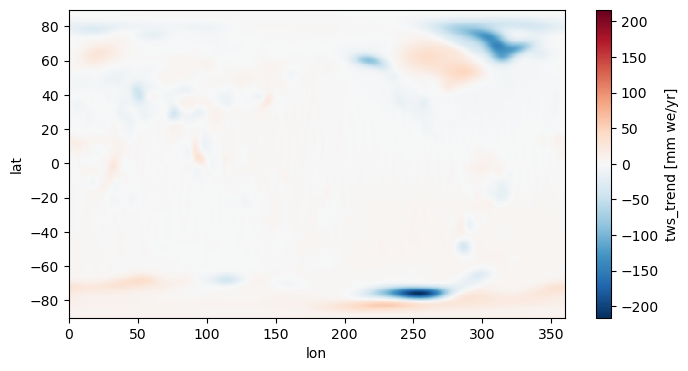

In [11]:
diff_rigid_vlm_xr.plot(figsize=(8, 4))

In [12]:
import xarray as xr
import numpy as np
import pandas as pd

# Baseline date for reference (e.g., 2006-12-31)
baseline_epoch = pd.Timestamp('2007-12-31')
# Prepare full time axis (monthly)
time_months = pd.date_range('2002-04-01', '2022-11-30', freq='MS')

# Compute elapsed years against baseline
years_since_baseline = ((time_months - baseline_epoch).days) / 365.25

# Create a 1D DataArray for years_since_baseline with a 'time' dimension
years_since_baseline_da = xr.DataArray(
    years_since_baseline, coords={'time': time_months}, dims='time'
)

# If solid_earth_factor_ipm_xr (shape [lat, lon]) does not have the 'time' dimension,
# use xr.broadcast to match: result will have [time, lat, lon]
factor_3d, years_3d = xr.broadcast(diff_rigid_vlm_xr, years_since_baseline_da) #diff_rigid_vlm_xr #diff_rigid_vlm_xr

# Now multiply elementwise, safely:
diff_rigid_vlm_EWH_absolute_solution = factor_3d * years_3d

# Set metadata
diff_rigid_vlm_EWH_absolute_solution.name = 'Secular TWS field (mm we)'
diff_rigid_vlm_EWH_absolute_solution.attrs['description'] = (
    "Difference of rigid earth TWS trend and vlm TWS trend propagated to the 3D TWS field - Secular TWS field"
    "using baseline epoch (2007-12-31) as zero reference"
)

# If you want to save:
diff_rigid_vlm_EWH_absolute_solution

<xarray.DataArray 'Secular TWS field (mm we)' (lat: 360, lon: 720, time: 248)> Size: 514MB
array([[[  1.83275144,   1.80656928,   1.77951437, ...,  -4.67613439,
          -4.70231655,  -4.72937145],
        [  1.82879976,   1.80267405,   1.77567748, ...,  -4.66605196,
          -4.69217768,  -4.71917424],
        [  1.82483891,   1.79876978,   1.77183168, ...,  -4.65594612,
          -4.68201525,  -4.70895335],
        ...,
        [  1.84454776,   1.81819707,   1.79096804, ...,  -4.70623184,
          -4.73258253,  -4.75981157],
        [  1.84062583,   1.81433118,   1.78716004, ...,  -4.69622534,
          -4.72252   ,  -4.74969114],
        [  1.83669354,   1.81045506,   1.78334196, ...,  -4.68619237,
          -4.71243085,  -4.73954395]],

       [[  2.25447721,   2.22227039,   2.18899001, ...,  -5.75213757,
          -5.78434438,  -5.81762476],
        [  2.2394711 ,   2.20747865,   2.17441979, ...,  -5.71385054,
          -5.74584299,  -5.77890185],
        [  2.22447289,   2.19269471,   2.15985725, ...,  -5.6755837 ,
          -5.70736188,  -5.74019934],
...
        [-40.47092643, -39.89277034, -39.29534238, ..., 103.258678  ,
         103.8368341 , 104.43426206],
        [-40.44743272, -39.86961225, -39.2725311 , ..., 103.19873549,
         103.77655596, 104.3736371 ],
        [-40.42396742, -39.84648217, -39.24974741, ..., 103.13886545,
         103.7163507 , 104.31308545]],

       [[-41.03676616, -40.45052665, -39.84474581, ..., 104.70237767,
         105.28861718, 105.89439802],
        [-41.0274544 , -40.44134791, -39.83570453, ..., 104.67861937,
         105.26472586, 105.87036924],
        [-41.01814209, -40.43216864, -39.82666273, ..., 104.65485969,
         105.24083314, 105.84633905],
        ...,
        [-41.0647172 , -40.47807838, -39.87188494, ..., 104.77369274,
         105.36033156, 105.96652501],
        [-41.05539895, -40.46889325, -39.86283736, ..., 104.7499179 ,
         105.3364236 , 105.94247949],
        [-41.04608285, -40.45971023, -39.85379187, ..., 104.72614852,
         105.31252113, 105.9184395 ]]], shape=(360, 720, 248))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-01 2002-05-01 ... 2022-11-01
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

In [13]:
diff_rigid_vlm_EWH_absolute_solution.to_netcdf(r'secular_TWS_fields_ITSG.nc')

-------

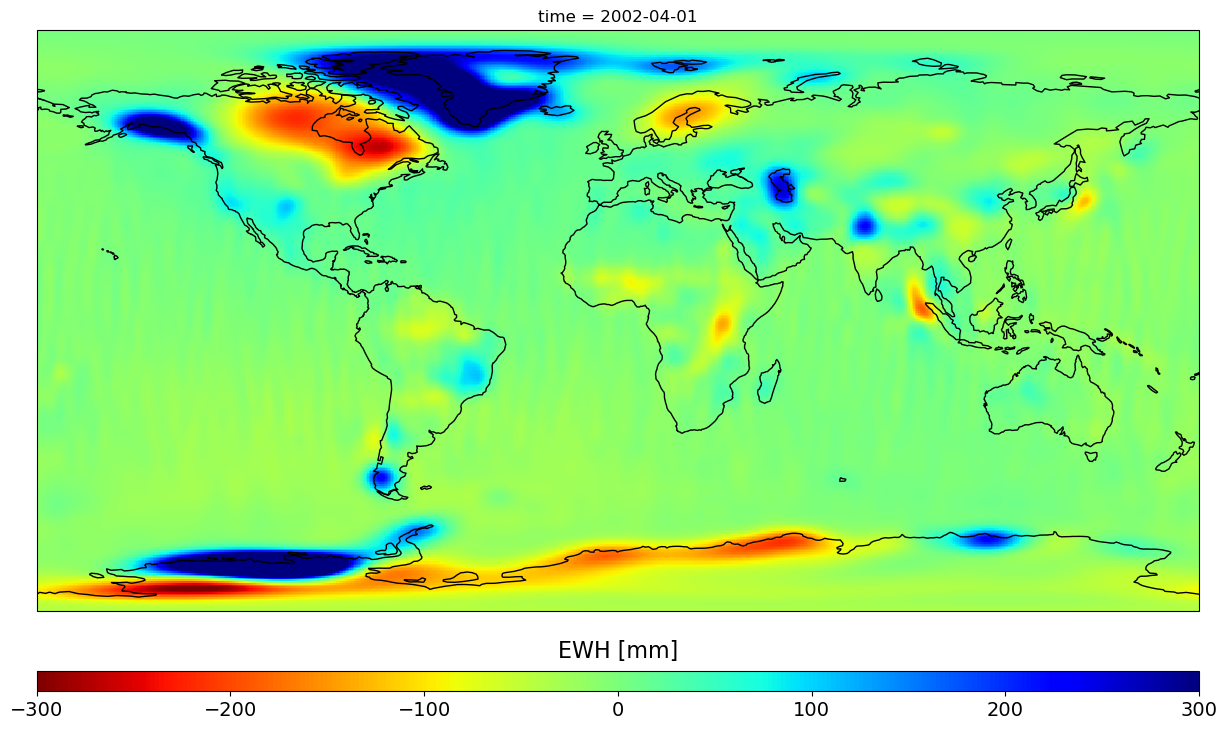

In [14]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm



# Select dataset variable
# gia11 = xr.open_dataset(r'CSR_GRACE_GRACE-FO_RL0603_Mascons_GIA-component_new.nc')


# tws_hhu = masked_solid_earth_correction_absolute_values['lwe_thickness'].isel(time=0)
tws_hhu = diff_rigid_vlm_EWH_absolute_solution.isel(time=0)

# tws_hhu = tws_hhu.transpose('lat', 'lon')

vmin = -300
vmax = 300
norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)  # keeps color centered on zero

fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# MAIN CHANGE: Do NOT pass 'levels' to imshow (or pcolormesh)
im = tws_hhu.plot.imshow(
    ax=ax,
    norm=norm,
    cmap='jet_r',  # continuous reversed jet colormap --- jet_r
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_title('Improved point mass solution (COST_G without Load Love number) - TWS Anomaly (April 2002)', fontsize=20, pad=15)

# Colorbar: by default matplotlib will give you a continuous colorbar
pos = ax.get_position()
cbar_left = pos.x0
cbar_width = pos.width * 1
cbar_bottom = pos.y0 - 0.08
cbar_height = 0.02

cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', shrink=0.9)
cbar.set_label('EWH [mm]', fontsize=16, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=14)

# plt.savefig('IPM_COSTG_without_K_continuous.png')
plt.show()

------

## computation of the non-secular componenets below

In [15]:
non_secular_TWS = xr.open_dataset(r'Non_secular_TWS_pysh_ITSG300_with_filtering_with_load_love_number.nc') 
non_secular_TWS

<xarray.Dataset> Size: 222MB
Dimensions:  (time: 214, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
  * lat      (lat) float64 3kB 89.0 88.5 88.0 87.5 ... -89.0 -89.5 -90.0 -90.5
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
Data variables:
    tws      (time, lat, lon) float32 222MB ...
Attributes:
    description:  Global gridded TWS Anomaly corresponding to long term (2004...
    units:        mm

In [16]:
# Assume `ds` is your xarray dataset
ds_non_secular_TWS = non_secular_TWS  # Replace with your actual dataset

# Shift latitude and longitude
shifted_lon = (ds_non_secular_TWS['lon'] + 360) % 360  # Wrap around [0, 360)
shifted_lat = (ds_non_secular_TWS['lat'] + 0.5)

# Update the dataset with the corrected coordinates
corrected_ds_non_secular_TWS = ds_non_secular_TWS.copy()
corrected_ds_non_secular_TWS = corrected_ds_non_secular_TWS.assign_coords(lon=shifted_lon, lat=shifted_lat)

# Sort longitude to ensure proper ordering after the shift
corrected_ds_non_secular_TWS = corrected_ds_non_secular_TWS.sortby('lon')

# Display the corrected dataset
corrected_ds_non_secular_TWS

<xarray.Dataset> Size: 222MB
Dimensions:  (time: 214, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
Data variables:
    tws      (time, lat, lon) float32 222MB ...
Attributes:
    description:  Global gridded TWS Anomaly corresponding to long term (2004...
    units:        mm

In [17]:
ds_non_secular_TWS_lwe = corrected_ds_non_secular_TWS.tws
ds_non_secular_TWS_lwe = ds_non_secular_TWS_lwe.resample(time='M').mean().interpolate_na(dim='time')
ds_non_secular_TWS_lwe

C:\Users\sudur\miniconda3\envs\Thesis\Lib\site-packages\xarray\groupers.py:498: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'tws' (time: 248, lat: 360, lon: 720)> Size: 257MB
array([[[ -8.7207775 ,  -8.730249  ,  -8.739756  , ...,  -8.692582  ,
          -8.701943  ,  -8.711342  ],
        [ -7.587422  ,  -7.6151896 ,  -7.6430507 , ...,  -7.504706  ,
          -7.532177  ,  -7.55975   ],
        [ -6.0734577 ,  -6.1241245 ,  -6.1748934 , ...,  -5.9221582 ,
          -5.972466  ,  -6.0229025 ],
        ...,
        [-47.408108  , -47.32461   , -47.241375  , ..., -47.66006   ,
         -47.57584   , -47.49185   ],
        [-46.255665  , -46.207905  , -46.1602    , ..., -46.39924   ,
         -46.351334  , -46.303474  ],
        [-45.465546  , -45.450005  , -45.434464  , ..., -45.512154  ,
         -45.49662   , -45.481083  ]],

       [[ -8.213498  ,  -8.219566  ,  -8.225694  , ...,  -8.195644  ,
          -8.201536  ,  -8.207487  ],
        [ -6.1381173 ,  -6.1597743 ,  -6.1815705 , ...,  -6.074003  ,
          -6.0952296 ,  -6.116602  ],
        [ -3.697878  ,  -3.7402694 ,  -3.7827692 , ...,  -3.5713887 ,
          -3.613434  ,  -3.6555984 ],
...
         110.92398   , 110.8414    ],
        [109.76938   , 109.70811   , 109.64684   , ..., 109.95328   ,
         109.89197   , 109.830666  ],
        [109.00775   , 108.98289   , 108.95803   , ..., 109.08232   ,
         109.057465  , 109.03261   ]],

       [[-10.940179  , -10.926121  , -10.912002  , ..., -10.981979  ,
         -10.96811   , -10.954176  ],
        [-13.264523  , -13.21229   , -13.159953  , ..., -13.420531  ,
         -13.36865   , -13.316646  ],
        [-16.328466  , -16.218607  , -16.108782  , ..., -16.658047  ,
         -16.548204  , -16.438337  ],
        ...,
        [105.24219   , 105.165665  , 105.08936   , ..., 105.47314   ,
         105.39592   , 105.31894   ],
        [104.24194   , 104.18565   , 104.12941   , ..., 104.411026  ,
         104.35463   , 104.29826   ],
        [103.36556   , 103.34259   , 103.31962   , ..., 103.43445   ,
         103.41149   , 103.38853   ]]],
      shape=(248, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
Attributes:
    units:    mm

In [18]:
ds_non_secular_TWS_lwe.to_netcdf(r'non_secular_TWS_fields_final_ITSG.nc')

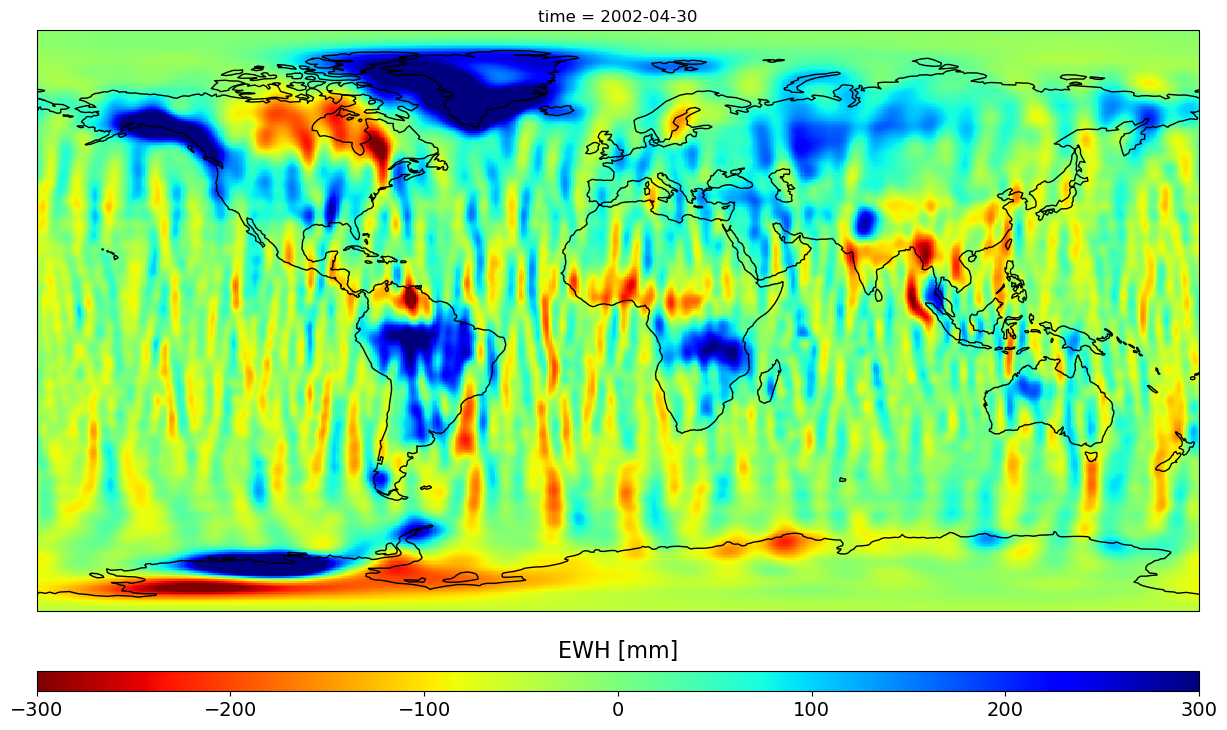

In [19]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm



# Select dataset variable
# gia11 = xr.open_dataset(r'CSR_GRACE_GRACE-FO_RL0603_Mascons_GIA-component_new.nc')


# tws_hhu = masked_solid_earth_correction_absolute_values['lwe_thickness'].isel(time=0)
tws_hhu = ds_non_secular_TWS_lwe.isel(time=0)

# tws_hhu = tws_hhu.transpose('lat', 'lon')

vmin = -300
vmax = 300
norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)  # keeps color centered on zero

fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# MAIN CHANGE: Do NOT pass 'levels' to imshow (or pcolormesh)
im = tws_hhu.plot.imshow(
    ax=ax,
    norm=norm,
    cmap='jet_r',  # continuous reversed jet colormap --- jet_r
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_title('Improved point mass solution (COST_G without Load Love number) - TWS Anomaly (April 2002)', fontsize=20, pad=15)

# Colorbar: by default matplotlib will give you a continuous colorbar
pos = ax.get_position()
cbar_left = pos.x0
cbar_width = pos.width * 1
cbar_bottom = pos.y0 - 0.08
cbar_height = 0.02

cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', shrink=0.9)
cbar.set_label('EWH [mm]', fontsize=16, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=14)

# plt.savefig('IPM_COSTG_without_K_continuous.png')
plt.show()

---------

## Total TWS_fields = Secular_TWS_fields + non-secular_TWS_fields

In [21]:
secular_aligned = diff_rigid_vlm_EWH_absolute_solution.transpose('time', 'lat', 'lon')
secular_aligned

<xarray.DataArray 'Secular TWS field (mm we)' (time: 248, lat: 360, lon: 720)> Size: 514MB
array([[[  1.83275144,   1.82879976,   1.82483891, ...,   1.84454776,
           1.84062583,   1.83669354],
        [  2.25447721,   2.2394711 ,   2.22447289, ...,   2.29952593,
           2.28450641,   2.26948946],
        [  2.86101991,   2.82831671,   2.79573408, ...,   2.95980376,
           2.92676827,   2.89383871],
        ...,
        [-39.14556577, -39.11365166, -39.08188751, ..., -39.24221429,
         -39.20984481, -39.17762939],
        [-40.40053345, -40.37713098, -40.35375745, ..., -40.47092643,
         -40.44743272, -40.42396742],
        [-41.03676616, -41.0274544 , -41.01814209, ..., -41.0647172 ,
         -41.05539895, -41.04608285]],

       [[  1.80656928,   1.80267405,   1.79876978, ...,   1.81819707,
           1.81433118,   1.81045506],
        [  2.22227039,   2.20747865,   2.19269471, ...,   2.26667556,
           2.2518706 ,   2.23706818],
        [  2.8201482 ,   2.78791219,   2.75579502, ...,   2.91752085,
           2.8849573 ,   2.85249816],
...
        [100.43633732, 100.35445483, 100.2729571 , ..., 100.68430981,
         100.60125897, 100.51860342],
        [103.65622582, 103.59618177, 103.53621198, ..., 103.8368341 ,
         103.77655596, 103.7163507 ],
        [105.28861718, 105.26472586, 105.24083314, ..., 105.36033156,
         105.3364236 , 105.31252113]],

       [[ -4.72937145,  -4.71917424,  -4.70895335, ...,  -4.75981157,
          -4.74969114,  -4.73954395],
        [ -5.81762476,  -5.77890185,  -5.74019934, ...,  -5.93387192,
          -5.89511439,  -5.85636351],
        [ -7.38279377,  -7.29840393,  -7.21432524, ...,  -7.63770313,
          -7.55245585,  -7.46748189],
        ...,
        [101.01420044, 100.93184683, 100.8498802 , ..., 101.26359964,
         101.18007096, 101.09693985],
        [104.25261464, 104.19222513, 104.1319103 , ..., 104.43426206,
         104.3736371 , 104.31308545],
        [105.89439802, 105.87036924, 105.84633905, ..., 105.96652501,
         105.94247949, 105.9184395 ]]], shape=(248, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-01 2002-05-01 ... 2022-11-01
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

In [22]:
secular_aligned_final = secular_aligned.assign_coords(time=ds_non_secular_TWS_lwe['time'].values)
secular_aligned_final

<xarray.DataArray 'Secular TWS field (mm we)' (time: 248, lat: 360, lon: 720)> Size: 514MB
array([[[  1.83275144,   1.82879976,   1.82483891, ...,   1.84454776,
           1.84062583,   1.83669354],
        [  2.25447721,   2.2394711 ,   2.22447289, ...,   2.29952593,
           2.28450641,   2.26948946],
        [  2.86101991,   2.82831671,   2.79573408, ...,   2.95980376,
           2.92676827,   2.89383871],
        ...,
        [-39.14556577, -39.11365166, -39.08188751, ..., -39.24221429,
         -39.20984481, -39.17762939],
        [-40.40053345, -40.37713098, -40.35375745, ..., -40.47092643,
         -40.44743272, -40.42396742],
        [-41.03676616, -41.0274544 , -41.01814209, ..., -41.0647172 ,
         -41.05539895, -41.04608285]],

       [[  1.80656928,   1.80267405,   1.79876978, ...,   1.81819707,
           1.81433118,   1.81045506],
        [  2.22227039,   2.20747865,   2.19269471, ...,   2.26667556,
           2.2518706 ,   2.23706818],
        [  2.8201482 ,   2.78791219,   2.75579502, ...,   2.91752085,
           2.8849573 ,   2.85249816],
...
        [100.43633732, 100.35445483, 100.2729571 , ..., 100.68430981,
         100.60125897, 100.51860342],
        [103.65622582, 103.59618177, 103.53621198, ..., 103.8368341 ,
         103.77655596, 103.7163507 ],
        [105.28861718, 105.26472586, 105.24083314, ..., 105.36033156,
         105.3364236 , 105.31252113]],

       [[ -4.72937145,  -4.71917424,  -4.70895335, ...,  -4.75981157,
          -4.74969114,  -4.73954395],
        [ -5.81762476,  -5.77890185,  -5.74019934, ...,  -5.93387192,
          -5.89511439,  -5.85636351],
        [ -7.38279377,  -7.29840393,  -7.21432524, ...,  -7.63770313,
          -7.55245585,  -7.46748189],
        ...,
        [101.01420044, 100.93184683, 100.8498802 , ..., 101.26359964,
         101.18007096, 101.09693985],
        [104.25261464, 104.19222513, 104.1319103 , ..., 104.43426206,
         104.3736371 , 104.31308545],
        [105.89439802, 105.87036924, 105.84633905, ..., 105.96652501,
         105.94247949, 105.9184395 ]]], shape=(248, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

In [23]:
secular_aligned_final = secular_aligned_final.rename('tws')

secular_aligned_final

<xarray.DataArray 'tws' (time: 248, lat: 360, lon: 720)> Size: 514MB
array([[[  1.83275144,   1.82879976,   1.82483891, ...,   1.84454776,
           1.84062583,   1.83669354],
        [  2.25447721,   2.2394711 ,   2.22447289, ...,   2.29952593,
           2.28450641,   2.26948946],
        [  2.86101991,   2.82831671,   2.79573408, ...,   2.95980376,
           2.92676827,   2.89383871],
        ...,
        [-39.14556577, -39.11365166, -39.08188751, ..., -39.24221429,
         -39.20984481, -39.17762939],
        [-40.40053345, -40.37713098, -40.35375745, ..., -40.47092643,
         -40.44743272, -40.42396742],
        [-41.03676616, -41.0274544 , -41.01814209, ..., -41.0647172 ,
         -41.05539895, -41.04608285]],

       [[  1.80656928,   1.80267405,   1.79876978, ...,   1.81819707,
           1.81433118,   1.81045506],
        [  2.22227039,   2.20747865,   2.19269471, ...,   2.26667556,
           2.2518706 ,   2.23706818],
        [  2.8201482 ,   2.78791219,   2.75579502, ...,   2.91752085,
           2.8849573 ,   2.85249816],
...
        [100.43633732, 100.35445483, 100.2729571 , ..., 100.68430981,
         100.60125897, 100.51860342],
        [103.65622582, 103.59618177, 103.53621198, ..., 103.8368341 ,
         103.77655596, 103.7163507 ],
        [105.28861718, 105.26472586, 105.24083314, ..., 105.36033156,
         105.3364236 , 105.31252113]],

       [[ -4.72937145,  -4.71917424,  -4.70895335, ...,  -4.75981157,
          -4.74969114,  -4.73954395],
        [ -5.81762476,  -5.77890185,  -5.74019934, ...,  -5.93387192,
          -5.89511439,  -5.85636351],
        [ -7.38279377,  -7.29840393,  -7.21432524, ...,  -7.63770313,
          -7.55245585,  -7.46748189],
        ...,
        [101.01420044, 100.93184683, 100.8498802 , ..., 101.26359964,
         101.18007096, 101.09693985],
        [104.25261464, 104.19222513, 104.1319103 , ..., 104.43426206,
         104.3736371 , 104.31308545],
        [105.89439802, 105.87036924, 105.84633905, ..., 105.96652501,
         105.94247949, 105.9184395 ]]], shape=(248, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

In [24]:
secular_aligned_final_slice = secular_aligned_final.sel(time=slice('2002-04', '2016-03'))
secular_aligned_final_slice

<xarray.DataArray 'tws' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[  1.83275144,   1.82879976,   1.82483891, ...,   1.84454776,
           1.84062583,   1.83669354],
        [  2.25447721,   2.2394711 ,   2.22447289, ...,   2.29952593,
           2.28450641,   2.26948946],
        [  2.86101991,   2.82831671,   2.79573408, ...,   2.95980376,
           2.92676827,   2.89383871],
        ...,
        [-39.14556577, -39.11365166, -39.08188751, ..., -39.24221429,
         -39.20984481, -39.17762939],
        [-40.40053345, -40.37713098, -40.35375745, ..., -40.47092643,
         -40.44743272, -40.42396742],
        [-41.03676616, -41.0274544 , -41.01814209, ..., -41.0647172 ,
         -41.05539895, -41.04608285]],

       [[  1.80656928,   1.80267405,   1.79876978, ...,   1.81819707,
           1.81433118,   1.81045506],
        [  2.22227039,   2.20747865,   2.19269471, ...,   2.26667556,
           2.2518706 ,   2.23706818],
        [  2.8201482 ,   2.78791219,   2.75579502, ...,   2.91752085,
           2.8849573 ,   2.85249816],
...
        [ 55.06476252,  55.01987   ,  54.97518843, ...,  55.20071477,
          55.1551817 ,  55.10986535],
        [ 56.83008372,  56.79716424,  56.76428548, ...,  56.92910318,
          56.89605536,  56.86304751],
        [ 57.72505107,  57.71195252,  57.69885321, ...,  57.76436886,
          57.75126119,  57.73815654]],

       [[ -2.60337978,  -2.59776652,  -2.59214022, ...,  -2.62013617,
          -2.61456517,  -2.60897944],
        [ -3.2024312 ,  -3.18111537,  -3.15981078, ...,  -3.26642184,
          -3.24508696,  -3.22375574],
        [ -4.06401067,  -4.01755655,  -3.9712737 , ...,  -4.20433077,
          -4.15740465,  -4.11062899],
        ...,
        [ 55.60534414,  55.56001091,  55.51489069, ...,  55.74263106,
          55.69665098,  55.65088975],
        [ 57.38799584,  57.3547532 ,  57.32155166, ...,  57.4879874 ,
          57.45461515,  57.42128325],
        [ 58.29174927,  58.27852213,  58.26529422, ...,  58.33145305,
          58.3182167 ,  58.3049834 ]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

In [25]:
secular_aligned_final_slice.to_netcdf(r'Secular_TWS_field_ready2use_ITSG.nc')

-------

In [26]:
non_secular_field = ds_non_secular_TWS_lwe
non_secular_field

<xarray.DataArray 'tws' (time: 248, lat: 360, lon: 720)> Size: 257MB
array([[[ -8.7207775 ,  -8.730249  ,  -8.739756  , ...,  -8.692582  ,
          -8.701943  ,  -8.711342  ],
        [ -7.587422  ,  -7.6151896 ,  -7.6430507 , ...,  -7.504706  ,
          -7.532177  ,  -7.55975   ],
        [ -6.0734577 ,  -6.1241245 ,  -6.1748934 , ...,  -5.9221582 ,
          -5.972466  ,  -6.0229025 ],
        ...,
        [-47.408108  , -47.32461   , -47.241375  , ..., -47.66006   ,
         -47.57584   , -47.49185   ],
        [-46.255665  , -46.207905  , -46.1602    , ..., -46.39924   ,
         -46.351334  , -46.303474  ],
        [-45.465546  , -45.450005  , -45.434464  , ..., -45.512154  ,
         -45.49662   , -45.481083  ]],

       [[ -8.213498  ,  -8.219566  ,  -8.225694  , ...,  -8.195644  ,
          -8.201536  ,  -8.207487  ],
        [ -6.1381173 ,  -6.1597743 ,  -6.1815705 , ...,  -6.074003  ,
          -6.0952296 ,  -6.116602  ],
        [ -3.697878  ,  -3.7402694 ,  -3.7827692 , ...,  -3.5713887 ,
          -3.613434  ,  -3.6555984 ],
...
         110.92398   , 110.8414    ],
        [109.76938   , 109.70811   , 109.64684   , ..., 109.95328   ,
         109.89197   , 109.830666  ],
        [109.00775   , 108.98289   , 108.95803   , ..., 109.08232   ,
         109.057465  , 109.03261   ]],

       [[-10.940179  , -10.926121  , -10.912002  , ..., -10.981979  ,
         -10.96811   , -10.954176  ],
        [-13.264523  , -13.21229   , -13.159953  , ..., -13.420531  ,
         -13.36865   , -13.316646  ],
        [-16.328466  , -16.218607  , -16.108782  , ..., -16.658047  ,
         -16.548204  , -16.438337  ],
        ...,
        [105.24219   , 105.165665  , 105.08936   , ..., 105.47314   ,
         105.39592   , 105.31894   ],
        [104.24194   , 104.18565   , 104.12941   , ..., 104.411026  ,
         104.35463   , 104.29826   ],
        [103.36556   , 103.34259   , 103.31962   , ..., 103.43445   ,
         103.41149   , 103.38853   ]]],
      shape=(248, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 2kB 2002-04-30 2002-05-31 ... 2022-11-30
Attributes:
    units:    mm

In [27]:
non_secular_field_slice = non_secular_field.sel(time=slice('2002-04', '2016-03'))
non_secular_field_slice

<xarray.DataArray 'tws' (time: 168, lat: 360, lon: 720)> Size: 174MB
array([[[ -8.7207775 ,  -8.730249  ,  -8.739756  , ...,  -8.692582  ,
          -8.701943  ,  -8.711342  ],
        [ -7.587422  ,  -7.6151896 ,  -7.6430507 , ...,  -7.504706  ,
          -7.532177  ,  -7.55975   ],
        [ -6.0734577 ,  -6.1241245 ,  -6.1748934 , ...,  -5.9221582 ,
          -5.972466  ,  -6.0229025 ],
        ...,
        [-47.408108  , -47.32461   , -47.241375  , ..., -47.66006   ,
         -47.57584   , -47.49185   ],
        [-46.255665  , -46.207905  , -46.1602    , ..., -46.39924   ,
         -46.351334  , -46.303474  ],
        [-45.465546  , -45.450005  , -45.434464  , ..., -45.512154  ,
         -45.49662   , -45.481083  ]],

       [[ -8.213498  ,  -8.219566  ,  -8.225694  , ...,  -8.195644  ,
          -8.201536  ,  -8.207487  ],
        [ -6.1381173 ,  -6.1597743 ,  -6.1815705 , ...,  -6.074003  ,
          -6.0952296 ,  -6.116602  ],
        [ -3.697878  ,  -3.7402694 ,  -3.7827692 , ...,  -3.5713887 ,
          -3.613434  ,  -3.6555984 ],
...
           1.000479  ,   1.0075403 ],
        [  0.24910986,   0.24710204,   0.24511118, ...,   0.25525764,
           0.2531854 ,   0.2511369 ],
        [ -0.12439148,  -0.12732626,  -0.13025177, ...,  -0.11553076,
          -0.11849379,  -0.12144734]],

       [[-28.4064    , -28.396597  , -28.386774  , ..., -28.435686  ,
         -28.425945  , -28.416183  ],
        [-29.238071  , -29.205664  , -29.17324   , ..., -29.335169  ,
         -29.302828  , -29.27046   ],
        [-30.32244   , -30.261282  , -30.200214  , ..., -30.506374  ,
         -30.444992  , -30.383678  ],
        ...,
        [ 26.311594  ,  26.299063  ,  26.286745  , ...,  26.350517  ,
          26.337318  ,  26.324347  ],
        [ 26.155022  ,  26.141994  ,  26.129078  , ...,  26.194788  ,
          26.181417  ,  26.168161  ],
        [ 26.41571   ,  26.409151  ,  26.402628  , ...,  26.4356    ,
          26.428936  ,  26.422306  ]]],
      shape=(168, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    units:    mm

In [28]:
non_secular_field_slice.to_netcdf(r'NonSecular_TWS_field_ready2use_ITSG.nc')

-------

In [29]:
ITSG_secular_TWS = xr.open_dataset(r'Secular_TWS_field_ready2use_ITSG.nc')
ITSG_secular_TWS

<xarray.Dataset> Size: 348MB
Dimensions:  (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Data variables:
    tws      (time, lat, lon) float64 348MB ...

In [30]:
ITSG_nonsecular_TWS = xr.open_dataset(r'NonSecular_TWS_field_ready2use_ITSG.nc')
ITSG_nonsecular_TWS

<xarray.Dataset> Size: 174MB
Dimensions:  (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Data variables:
    tws      (time, lat, lon) float32 174MB ...

In [31]:
total_TWS_fields = (ITSG_secular_TWS['tws'] + ITSG_nonsecular_TWS['tws'])
# Optionally reconstruct DataArray after subtraction:
total_TWS_fields_xr = xr.DataArray(
    total_TWS_fields,
    coords=ITSG_secular_TWS['tws'].coords,
    dims=ITSG_secular_TWS['tws'].dims,
    attrs=ITSG_secular_TWS['tws'].attrs
)
total_TWS_fields_xr

<xarray.DataArray 'tws' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[ -6.88802607,  -6.90144964,  -6.91491673, ...,  -6.84803437,
          -6.86131756,  -6.87464832],
        [ -5.33294468,  -5.37571845,  -5.41857778, ...,  -5.20517997,
          -5.24767057,  -5.29026062],
        [ -3.2124378 ,  -3.29580782,  -3.3791593 , ...,  -2.96235448,
          -3.04569772,  -3.12906378],
        ...,
        [-86.55367353, -86.43826332, -86.32326248, ..., -86.90227517,
         -86.78568481, -86.6694812 ],
        [-86.65619827, -86.58503579, -86.51395566, ..., -86.87016502,
         -86.79876634, -86.72744185],
        [-86.50231182, -86.47745898, -86.4526056 , ..., -86.57687083,
         -86.55201913, -86.52716576]],

       [[ -6.40692884,  -6.41689229,  -6.42692392, ...,  -6.37744731,
          -6.387205  ,  -6.39703205],
        [ -3.91584692,  -3.95229565,  -3.98887582, ...,  -3.80732766,
          -3.84335903,  -3.87953377],
        [ -0.87772968,  -0.95235724,  -1.02697418, ...,  -0.65386787,
          -0.72847678,  -0.80310024],
...
        [ 56.07941596,  56.04168065,  56.00419313, ...,  56.19419164,
          56.15566068,  56.11740569],
        [ 57.07919358,  57.04426628,  57.00939666, ...,  57.18436081,
          57.14924075,  57.1141844 ],
        [ 57.60065959,  57.58462626,  57.56860145, ...,  57.6488381 ,
          57.6327674 ,  57.6167092 ]],

       [[-31.00978046, -30.99436343, -30.97891428, ..., -31.05582228,
         -31.04051046, -31.02516291],
        [-32.44050264, -32.38677905, -32.33305144, ..., -32.60159068,
         -32.54791479, -32.49421587],
        [-34.38644986, -34.27883851, -34.17148809, ..., -34.71070513,
         -34.60239671, -34.49430742],
        ...,
        [ 81.91693815,  81.85907364,  81.80163576, ...,  82.09314833,
          82.03396941,  81.9752363 ],
        [ 83.54301751,  83.49674767,  83.45062957, ...,  83.68277538,
          83.63603261,  83.58944464],
        [ 84.70745972,  84.68767321,  84.66792217, ...,  84.76705333,
          84.74715271,  84.72728946]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    description:  Difference of rigid earth TWS trend and vlm TWS trend propa...

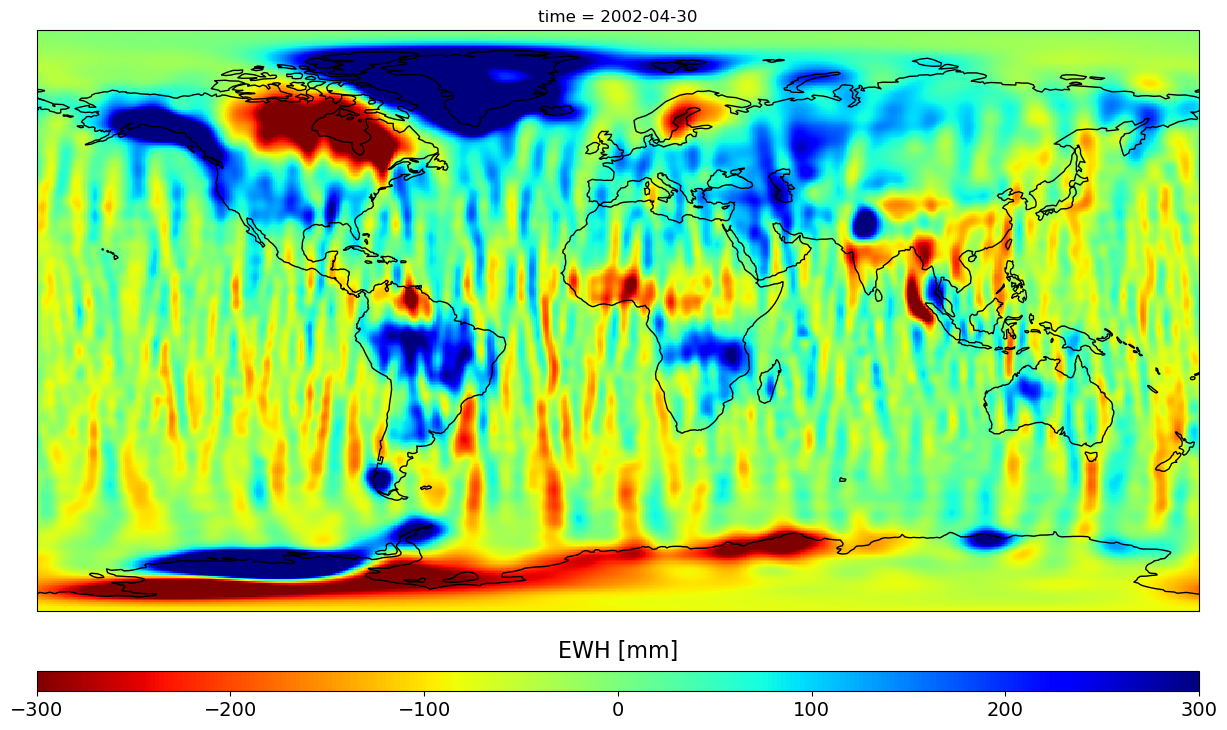

In [32]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm

# tws_hhu = masked_solid_earth_correction_absolute_values['lwe_thickness'].isel(time=0)
tws_hhu = total_TWS_fields_xr.isel(time=0)

# tws_hhu = tws_hhu.transpose('lat', 'lon')

vmin = -300
vmax = 300
norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)  # keeps color centered on zero

fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# MAIN CHANGE: Do NOT pass 'levels' to imshow (or pcolormesh)
im = tws_hhu.plot.imshow(
    ax=ax,
    norm=norm,
    cmap='jet_r',  # continuous reversed jet colormap --- jet_r
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_title('Improved point mass solution (COST_G without Load Love number) - TWS Anomaly (April 2002)', fontsize=20, pad=15)

# Colorbar: by default matplotlib will give you a continuous colorbar
pos = ax.get_position()
cbar_left = pos.x0
cbar_width = pos.width * 1
cbar_bottom = pos.y0 - 0.08
cbar_height = 0.02

cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', shrink=0.9)
cbar.set_label('EWH [mm]', fontsize=16, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=14)

# plt.savefig('IPM_COSTG_without_K_continuous.png')
plt.show()

In [33]:
total_TWS_fields_xr.to_netcdf(r'Total_TWS_fields_solid_earth_corrected_ITSG_solutions.nc')

--------

In [34]:
Half_degree_SF = xr.open_dataset(r'Scale_factor_half_degree_renamed_full_range.nc')
Half_degree_SF

<xarray.Dataset> Size: 2MB
Dimensions:       (lon: 720, lat: 360)
Coordinates:
  * lon           (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat           (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -89.0 -89.5 -90.0
Data variables:
    SCALE_FACTOR  (lat, lon) float64 2MB ...

In [35]:
total_TWS_fields_itsg = xr.open_dataset(r'Total_TWS_fields_solid_earth_corrected_ITSG_solutions.nc')
total_TWS_fields_itsg

<xarray.Dataset> Size: 348MB
Dimensions:  (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Data variables:
    tws      (time, lat, lon) float64 348MB ...

------

In [37]:
scaled_tws_field_itsg = total_TWS_fields_itsg['tws'] * Half_degree_SF['SCALE_FACTOR']
scaled_tws_field_itsg

<xarray.DataArray (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[ -6.88802607,  -6.90144964,  -6.91491673, ...,  -6.84803437,
          -6.86131756,  -6.87464832],
        [ -5.33294468,  -5.37571845,  -5.41857778, ...,  -5.20517997,
          -5.24767057,  -5.29026062],
        [ -3.2124378 ,  -3.29580782,  -3.3791593 , ...,  -2.96235448,
          -3.04569772,  -3.12906378],
        ...,
        [-86.55367353, -86.43826332, -86.32326248, ..., -86.90227517,
         -86.78568481, -86.6694812 ],
        [-86.65619827, -86.58503579, -86.51395566, ..., -86.87016502,
         -86.79876634, -86.72744185],
        [-86.50231182, -86.47745898, -86.4526056 , ..., -86.57687083,
         -86.55201913, -86.52716576]],

       [[ -6.40692884,  -6.41689229,  -6.42692392, ...,  -6.37744731,
          -6.387205  ,  -6.39703205],
        [ -3.91584692,  -3.95229565,  -3.98887582, ...,  -3.80732766,
          -3.84335903,  -3.87953377],
        [ -0.87772968,  -0.95235724,  -1.02697418, ...,  -0.65386787,
          -0.72847678,  -0.80310024],
...
        [ 56.07941596,  56.04168065,  56.00419313, ...,  56.19419164,
          56.15566068,  56.11740569],
        [ 57.07919358,  57.04426628,  57.00939666, ...,  57.18436081,
          57.14924075,  57.1141844 ],
        [ 57.60065959,  57.58462626,  57.56860145, ...,  57.6488381 ,
          57.6327674 ,  57.6167092 ]],

       [[-31.00978046, -30.99436343, -30.97891428, ..., -31.05582228,
         -31.04051046, -31.02516291],
        [-32.44050264, -32.38677905, -32.33305144, ..., -32.60159068,
         -32.54791479, -32.49421587],
        [-34.38644986, -34.27883851, -34.17148809, ..., -34.71070513,
         -34.60239671, -34.49430742],
        ...,
        [ 81.91693815,  81.85907364,  81.80163576, ...,  82.09314833,
          82.03396941,  81.9752363 ],
        [ 83.54301751,  83.49674767,  83.45062957, ...,  83.68277538,
          83.63603261,  83.58944464],
        [ 84.70745972,  84.68767321,  84.66792217, ...,  84.76705333,
          84.74715271,  84.72728946]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31

In [38]:
scaled_tws_field_itsg.to_netcdf(r'Scaled_total_TWS_ITSG_field.nc')

------

In [39]:
scaled_grace_tws_meters = scaled_tws_field_itsg * 0.001
scaled_grace_tws_meters

<xarray.DataArray (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.00688803, -0.00690145, -0.00691492, ..., -0.00684803,
         -0.00686132, -0.00687465],
        [-0.00533294, -0.00537572, -0.00541858, ..., -0.00520518,
         -0.00524767, -0.00529026],
        [-0.00321244, -0.00329581, -0.00337916, ..., -0.00296235,
         -0.0030457 , -0.00312906],
        ...,
        [-0.08655367, -0.08643826, -0.08632326, ..., -0.08690228,
         -0.08678568, -0.08666948],
        [-0.0866562 , -0.08658504, -0.08651396, ..., -0.08687017,
         -0.08679877, -0.08672744],
        [-0.08650231, -0.08647746, -0.08645261, ..., -0.08657687,
         -0.08655202, -0.08652717]],

       [[-0.00640693, -0.00641689, -0.00642692, ..., -0.00637745,
         -0.0063872 , -0.00639703],
        [-0.00391585, -0.0039523 , -0.00398888, ..., -0.00380733,
         -0.00384336, -0.00387953],
        [-0.00087773, -0.00095236, -0.00102697, ..., -0.00065387,
         -0.00072848, -0.0008031 ],
...
        [ 0.05607942,  0.05604168,  0.05600419, ...,  0.05619419,
          0.05615566,  0.05611741],
        [ 0.05707919,  0.05704427,  0.0570094 , ...,  0.05718436,
          0.05714924,  0.05711418],
        [ 0.05760066,  0.05758463,  0.0575686 , ...,  0.05764884,
          0.05763277,  0.05761671]],

       [[-0.03100978, -0.03099436, -0.03097891, ..., -0.03105582,
         -0.03104051, -0.03102516],
        [-0.0324405 , -0.03238678, -0.03233305, ..., -0.03260159,
         -0.03254791, -0.03249422],
        [-0.03438645, -0.03427884, -0.03417149, ..., -0.03471071,
         -0.0346024 , -0.03449431],
        ...,
        [ 0.08191694,  0.08185907,  0.08180164, ...,  0.08209315,
          0.08203397,  0.08197524],
        [ 0.08354302,  0.08349675,  0.08345063, ...,  0.08368278,
          0.08363603,  0.08358944],
        [ 0.08470746,  0.08468767,  0.08466792, ...,  0.08476705,
          0.08474715,  0.08472729]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31

In [40]:
scaled_grace_tws_meters.to_netcdf('ITSGscaled_grace_tws_meters_solid_earth_corrected_scaled_usingCLM4.nc')

-----------

In [41]:
ds = xr.open_dataset(r'ITSGscaled_grace_tws_meters_solid_earth_corrected_scaled_usingCLM4.nc')
ds

<xarray.Dataset> Size: 348MB
Dimensions:                        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon                            (lon) float64 6kB 0.0 0.5 1.0 ... 359.0 359.5
  * lat                            (lat) float64 3kB 89.5 89.0 ... -89.5 -90.0
  * time                           (time) datetime64[ns] 1kB 2002-04-30 ... 2...
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float64 348MB ...

In [42]:
ds_renamed = ds.rename({'__xarray_dataarray_variable__': 'lwe_thickness'})
ds_renamed

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -89.0 -89.5 -90.0
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB ...

In [43]:
ds_renamed.to_netcdf(r'ITSGscaled_grace_tws_meters_solid_earth_corrected_scaled_usingCLM4_renamed.nc')

-------

In [44]:
# 1. Load and prepare the shapefile
gdf = gpd.read_file(r'D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_TotalHMA_boundary1_22.shp')
gdf_4326 = gdf.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf_4326 = gdf_4326.drop(['Primary__1', 'Glacier_Ar'], axis=1)
dropped_gdf_4326

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,111147.061871,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,211514.200081,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,166943.561268,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,270268.094462,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,92830.485352,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,124880.500694,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,83444.425531,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,205724.916795,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,39543.166059,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,132813.049169,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [45]:
gdf1 = gpd.read_file(r"D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_SingleHMAboundarythatincludes1to22.shp")
gdf1_4326 = gdf1.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf1_4326 = gdf1_4326.drop(['Primary__1', 'Glacier_Ar'], axis=1)  #already done , so comes weror wehn done
dropped_gdf1_4326

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,High Mountain Asia Region,3.993978e+06,3.993978e+12,23,"POLYGON ((92.26394 39.3763, 92.24847 39.32136,..."


In [46]:
gdf_concat = pd.concat([dropped_gdf_4326, dropped_gdf1_4326 ], axis=0, ignore_index=True)
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [48]:
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray
from shapely.geometry import mapping

# # 1. Load and prepare the shapefile
# gdf = gpd.read_file(r'D:/MSRSGI/Masters_thesis/Data/HMA_Region_Shapefiles/Regions_shapefiles/HMA_region_annoted_final.shp')
# gdf_4326 = gdf.to_crs('EPSG:4326')  # Reproject to match dataset CRS

# 2. Load the lwe_thickness dataset 
ds = xr.open_dataset(r'ITSGscaled_grace_tws_meters_solid_earth_corrected_scaled_usingCLM4_renamed.nc') #SE_corrected_Total_TWS_full_range.nc #Total_SE_corrected_GARCE_feild_without_leakage.nc
da = ds['lwe_thickness']  # Get the DataArray
# da = da.transpose('time', 'lat', 'lon')


# 3. Define the provided functions
def area_weighting(grid_resolution):
    """
    Calculate the area of each grid, globally, corresponding to the latitudes and longitudes.
    """
    longitude_grid = np.linspace(0, 359+(1-grid_resolution), int(360/grid_resolution), dtype='float')
    latitude_grid = np.linspace(0, 179+(1-grid_resolution), int(180/grid_resolution), dtype='float')
    longitude_grid1 = np.linspace(1*grid_resolution, 360, int(360/grid_resolution), dtype='float')
    latitude_grid1 = np.linspace(1*grid_resolution, 180, int(180/grid_resolution), dtype='float')
    
    lambd,theta = np.meshgrid(longitude_grid, latitude_grid)  
    lambd1,theta1 = np.meshgrid(longitude_grid1, latitude_grid1)
    
    delta_latitude = np.sin(np.deg2rad(90-theta)) - np.sin(np.deg2rad(90-theta1))
    delta_longitude = (lambd1 - lambd) * np.pi/180

    # Area of each grid in m²
    area = (6378.137**2) * pow(10,6) * (np.multiply(delta_latitude, delta_longitude))
    return area

def Basinaverage(temp, gs, shp_basin, basin_area):
    """
    Calculate the basin average of the total water storage (TWS).
    """
    # Apply area weighting to the data
    temp_weighted = temp.copy()
    temp_weighted = temp * area_weighting(gs)  # Convert to volume
    
    # Set spatial dimensions and CRS
    basin_tws = temp_weighted.rio.write_crs("EPSG:4326", inplace=True)
    basin_tws = basin_tws.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            
    # Clip data to basin shape
    basin_tws = basin_tws.rio.clip(shp_basin.geometry.apply(mapping), shp_basin.crs, drop=True)
    
    # Calculate basin average TWS
    basin_avg_tws = basin_tws.sum(dim=('lon','lat'), skipna=True) / basin_area
    
    # Clean up spatial references
    if 'spatial_ref' in basin_avg_tws.coords:
        basin_avg_tws = basin_avg_tws.drop_vars('spatial_ref')
    
    return basin_avg_tws

# 4. Process each region
results = []
grid_resolution = 0.5  # Grid resolution in degrees

#for idx, region in gdf_4326.iterrows():
for idx, region in gdf_concat.iterrows():
    region_name = region.Primary_ID
    region_area = region.Shape_Area  # Exact region area from shapefile
    number_region = region.Region_No #latest
    
    #  GeoDataFrame
    region_gdf = gpd.GeoDataFrame({
        'geometry': [region.geometry],
        'Primary_ID': [region_name],
        'Region_No': [number_region],
        'Shape_Area': [region_area]
    }, crs=gdf_concat.crs)   #gdf_4326 is replaced by gdf_concat
    
    # Calculate the basin average using the reference function
    basin_avg = Basinaverage(da, grid_resolution, region_gdf, region_area)
    
    # # Add region metadata
    # basin_avg = basin_avg.assign_attrs({
    #     'region_name': region_name,
    #     #'region_area_m2': float(region_area),
    #     'region_area_m2': region_area,
    #     'region_id': number_region
    # })

    meta = xr.Dataset({
    'region_id': result_ds.region_id,
    'region_area_m2': result_ds.region_area_m2}, coords={'region': result_ds.region})

    # print(meta.to_dataframe())
    
    basin_avg = basin_avg.expand_dims(region=[region_name])
    basin_avg = basin_avg.assign_coords({
    'region_area_m2': ('region', [region_area]),
    'region_id': ('region', [number_region])})
    results.append(basin_avg)

# 5. Combine all regions into a single dataset
result_ds = xr.concat(results, dim='region')

In [49]:
result_ds

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[ 0.02020636,  0.20950331,  0.12518955, ..., -0.10620417,
        -0.05040699, -0.00312041],
       [ 0.57670247,  0.38363543,  0.35928059, ..., -0.51267913,
        -0.50366082, -0.48151718],
       [ 0.00088585,  0.068343  ,  0.1161271 , ..., -0.25680207,
        -0.25211827, -0.2675223 ],
       ...,
       [ 0.05890014,  0.05875024,  0.05805483, ..., -0.07685094,
        -0.06638238, -0.08143834],
       [ 0.01821242,  0.01864738,  0.00995522, ..., -0.03393836,
        -0.02931844, -0.03188715],
       [ 0.00552901,  0.01528428,  0.02165307, ..., -0.09073169,
        -0.07952319, -0.09703847]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23

In [50]:
result_ds_mm = result_ds * 1000
result_ds_mm

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[  20.2063551 ,  209.50330983,  125.18954795, ..., -106.20416656,
         -50.40698802,   -3.12040781],
       [ 576.70247034,  383.63542578,  359.28058844, ..., -512.67912531,
        -503.66081964, -481.51718253],
       [   0.88585241,   68.34300086,  116.12709908, ..., -256.80206511,
        -252.11826967, -267.52229826],
       ...,
       [  58.90013813,   58.75024333,   58.05482779, ...,  -76.85093662,
         -66.38237626,  -81.43833968],
       [  18.21242495,   18.64738145,    9.95522159, ...,  -33.93836311,
         -29.31843965,  -31.88715242],
       [   5.52900738,   15.28427918,   21.65306527, ...,  -90.73168685,
         -79.52318957,  -97.03846624]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23

In [51]:
result_ds_mm.attrs['units'] = 'mm'

In [52]:
result_ds_mm

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[  20.2063551 ,  209.50330983,  125.18954795, ..., -106.20416656,
         -50.40698802,   -3.12040781],
       [ 576.70247034,  383.63542578,  359.28058844, ..., -512.67912531,
        -503.66081964, -481.51718253],
       [   0.88585241,   68.34300086,  116.12709908, ..., -256.80206511,
        -252.11826967, -267.52229826],
       ...,
       [  58.90013813,   58.75024333,   58.05482779, ...,  -76.85093662,
         -66.38237626,  -81.43833968],
       [  18.21242495,   18.64738145,    9.95522159, ...,  -33.93836311,
         -29.31843965,  -31.88715242],
       [   5.52900738,   15.28427918,   21.65306527, ...,  -90.73168685,
         -79.52318957,  -97.03846624]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23
Attributes:
    units:    mm

In [53]:
meta.to_dataframe()

,region_area_m2,region_id
region,,
Eastern Hindu Kush,1.111471e+11,8
Western Himalaya,2.115142e+11,10
Eastern Himalaya,1.669436e+11,12
Central Himalaya,2.702681e+11,11
Karakoram,9.283049e+10,9
Western Pamir,1.248805e+11,6
Pamir Alay,8.344443e+10,5
Northern/Western Tien Shan,2.057249e+11,4
Dzhungarsky Alatau,3.954317e+10,1


In [54]:
# 6. Save to NetCDF
# result_ds_mm.to_netcdf(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_HMA_regional_averages_WeightedMeanMascon_mm_End.nc')

result_ds_mm.to_netcdf(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_SECorrected_HMA_RA_sol_scaled.nc')

In [55]:
# Load the dataset
# ds = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_HMA_regional_averages_WeightedMeanMascon_mm_End.nc')

ds = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_SECorrected_HMA_RA_sol_scaled.nc')

# Rearrange dimensions to (time, region)
da = ds['lwe_thickness'].transpose('time', 'region')

# Convert to pandas DataFrame
df = da.to_pandas()  # time as index, region names as columns
df

region,Eastern Hindu Kush,Western Himalaya,Eastern Himalaya,Central Himalaya,Karakoram,Western Pamir,Pamir Alay,Northern/Western Tien Shan,Dzhungarsky Alatau,Western Kunlun Shan,...,Tibetan Interior Mountains,Tanggula Shan,Eastern Tibetan Mountains,Qilian Shan,Eastern Kunlun Shan,Altun Shan,Eastern Tien Shan,Central Tien Shan,Eastern Pamir,High Mountain Asia Region
time,,,,,,,,,,,,,,,,,,,,,
2002-04-30,20.206355,576.702470,0.885852,171.145055,143.627436,40.212573,60.532807,63.386666,124.521092,-20.876463,...,-134.073090,-30.649280,-99.335932,-63.618062,-245.828192,-66.554154,45.042233,58.900138,18.212425,5.529007
2002-05-31,209.503310,383.635426,68.343001,131.431170,93.490518,152.059030,128.421928,81.250074,118.353113,-23.609067,...,-127.529050,3.286940,-81.932208,-49.502493,-199.843760,-52.761212,50.814128,58.750243,18.647381,15.284279
2002-06-30,125.189548,359.280588,116.127099,184.188963,55.736778,97.530431,76.513555,64.905420,112.527263,-19.847062,...,-116.631192,13.363552,-73.823440,-45.157170,-194.054141,-54.115778,47.455775,58.054828,9.955222,21.653065
2002-07-31,38.110666,334.317259,165.556938,238.802585,16.788186,41.225090,22.903308,48.054281,106.547219,-15.965348,...,-105.410712,23.798184,-65.472490,-40.685283,-188.154754,-55.539590,44.012859,57.363714,0.985558,28.250912
2002-08-31,-48.990513,309.253930,214.960742,293.368385,-22.191687,-15.100356,-30.720909,31.184288,100.547502,-12.080835,...,-94.170246,34.221931,-57.107715,-36.204406,-182.214438,-56.951551,40.556477,56.659085,-7.990123,34.840513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,-189.625205,-443.788514,-146.249634,-293.682577,-157.494911,-172.743774,-140.720426,-127.860332,-127.553111,3.781727,...,46.737799,-113.835317,22.710096,29.622001,166.419434,63.463948,-84.270607,-85.184713,-34.069381,-70.160176
2015-12-31,-160.457983,-501.746028,-215.346340,-350.405766,-169.795289,-147.085487,-130.444117,-103.532228,-90.781126,5.853544,...,17.305507,-138.673601,-6.000911,21.230721,135.645007,51.415044,-86.196883,-76.827552,-34.279324,-93.801906
2016-01-31,-106.204167,-512.679125,-256.802065,-368.364812,-168.684514,-107.543763,-66.544070,-82.671381,-78.094162,3.171361,...,45.435250,-151.227879,-10.900979,8.693123,173.994940,57.600146,-54.802697,-76.850937,-33.938363,-90.731687


In [56]:
# Your region metadata
region_metadata_s = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Pamir Alay', 'Northern/Western Tien Shan', 'Dzhungarsky Alatau', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan', 'Altun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'Eastern Pamir', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 5, 4, 1, 13, 18, 17, 20, 16, 19, 21, 22, 14, 15, 2, 3, 7, 23]
})

# Sort by region_id
region_metadata_sorted_s = region_metadata_s.sort_values(by='region_id')
sorted_columns_s = region_metadata_sorted_s['region'].tolist()

df_s = df[sorted_columns_s]

df_s.index.name = 'time'
# df_s.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_EnsembleWeightedAverageMascon.csv', index=True)

df_s.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_SECorerected_RA_sol_scaled_region_sorted.csv', index=True)

In [57]:
SEgrace_mmwe = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_SECorerected_RA_sol_scaled_region_sorted.csv')
SEgrace_mmwe

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,124.521092,45.042233,58.900138,63.386666,60.532807,40.212573,18.212425,20.206355,143.627436,...,-245.828192,-66.554154,-134.073090,22.180198,20.909818,-30.649280,-44.899316,-99.335932,-63.618062,5.529007
1,2002-05-31,118.353113,50.814128,58.750243,81.250074,128.421928,152.059030,18.647381,209.503310,93.490518,...,-199.843760,-52.761212,-127.529050,17.029605,84.129951,3.286940,-46.931918,-81.932208,-49.502493,15.284279
2,2002-06-30,112.527263,47.455775,58.054828,64.905420,76.513555,97.530431,9.955222,125.189548,55.736778,...,-194.054141,-54.115778,-116.631192,33.077388,98.749389,13.363552,3.506488,-73.823440,-45.157170,21.653065
3,2002-07-31,106.547219,44.012859,57.363714,48.054281,22.903308,41.225090,0.985558,38.110666,16.788186,...,-188.154754,-55.539590,-105.410712,49.677969,113.908643,23.798184,55.618667,-65.472490,-40.685283,28.250912
4,2002-08-31,100.547502,40.556477,56.659085,31.184288,-30.720909,-15.100356,-7.990123,-48.990513,-22.191687,...,-182.214438,-56.951551,-94.170246,66.269761,129.042076,34.221931,107.734539,-57.107715,-36.204406,34.840513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-127.553111,-84.270607,-85.184713,-127.860332,-140.720426,-172.743774,-34.069381,-189.625205,-157.494911,...,166.419434,63.463948,46.737799,-92.639407,-173.412448,-113.835317,43.777218,22.710096,29.622001,-70.160176
164,2015-12-31,-90.781126,-86.196883,-76.827552,-103.532228,-130.444117,-147.085487,-34.279324,-160.457983,-169.795289,...,135.645007,51.415044,17.305507,-110.882981,-211.840850,-138.673601,-8.545210,-6.000911,21.230721,-93.801906
165,2016-01-31,-78.094162,-54.802697,-76.850937,-82.671381,-66.544070,-107.543763,-33.938363,-106.204167,-168.684514,...,173.994940,57.600146,45.435250,-108.536742,-232.487887,-151.227879,-50.246994,-10.900979,8.693123,-90.731687
166,2016-02-29,-38.438039,-47.881990,-66.382376,-68.101156,-37.231471,-78.654959,-29.318440,-50.406988,-148.590614,...,180.702349,59.549226,51.054302,-96.827826,-217.662287,-129.520137,-56.988104,1.184168,25.310133,-79.523190


In [58]:
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [59]:
# Set index on region name for area lookup; adjust 'region' to your actual column name
area_series = gdf_concat.set_index('Primary_ID')['Shape_Area']

# Prepare grace signal DataFrame with time as index
mm_data_grace_SE = SEgrace_mmwe.set_index('time')

# Ensure area order matches the column order of glacier signal
area = area_series.loc[mm_data_grace_SE.columns]

# Convert mm to Gt: multiply each region column by its area and divide by 1e12
signal_gt_grace_SE = mm_data_grace_SE.multiply(area, axis=1) / 1e12

# Optional: reset index if needed or save
signal_gt_grace_SE = signal_gt_grace_SE.reset_index()
signal_gt_grace_SE

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,4.923958,6.495472,6.593702,13.040217,5.051125,5.021766,0.800901,2.245877,13.333005,...,-64.179262,-3.743021,-73.199213,3.627895,3.633786,-4.478242,-16.738359,-33.121856,-12.836048,22.082734
1,2002-05-31,4.680057,7.327829,6.576922,16.715165,10.716094,18.989208,0.820029,23.285677,8.678770,...,-52.173939,-2.967303,-69.626396,2.785440,14.620416,0.480263,-17.496108,-27.318884,-9.987987,61.045075
2,2002-06-30,4.449684,6.843526,6.499072,13.352662,6.384630,12.179649,0.437786,13.914450,5.174072,...,-50.662422,-3.043484,-63.676547,5.410289,17.161036,1.952581,1.307210,-24.615155,-9.111242,86.481867
3,2002-07-31,4.213214,6.347028,6.421704,9.885963,1.911153,5.148210,0.043340,4.235889,1.558455,...,-49.122248,-3.123559,-57.550558,8.125557,19.795467,3.477211,20.734508,-21.830674,-8.208962,112.833524
4,2002-08-31,3.975967,5.848588,6.342823,6.415385,-2.563489,-1.885740,-0.351370,-5.445152,-2.060065,...,-47.571388,-3.202968,-51.413657,10.839386,22.425411,5.000251,40.163182,-19.041584,-7.304867,139.152244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-5.043854,-12.152537,-9.536185,-26.304056,-11.742335,-21.572329,-1.498219,-21.076284,-14.620329,...,43.447728,3.569227,25.517202,-15.152527,-30.136259,-16.632758,16.320044,7.572291,5.976753,-280.218204
164,2015-12-31,-3.589773,-12.430322,-8.600625,-21.299159,-10.884834,-18.368109,-1.507452,-17.834433,-15.762179,...,35.413336,2.891594,9.448201,-18.136529,-36.814490,-20.261941,-3.185634,-2.000900,4.283666,-374.642751
165,2016-01-31,-3.088090,-7.903014,-8.603243,-17.007563,-5.552732,-13.430119,-1.492458,-11.804281,-15.659065,...,45.425493,3.239445,24.806056,-17.752767,-40.402609,-22.096277,-18.731961,-3.634744,1.753988,-362.380364
166,2016-02-29,-1.519962,-6.904989,-7.431317,-14.010105,-3.106759,-9.822471,-1.289294,-5.602589,-13.793739,...,47.176621,3.349062,27.873862,-15.837603,-37.826161,-18.924506,-21.245031,0.394840,5.106759,-317.613872


In [60]:
signal_gt_grace_SE.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_Updated_HMA_RA_TWS_SE_corrected_GRACE_Signal_inGT_scaled.csv', index=False)

In [61]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/ITSG_Updated_HMA_RA_TWS_SE_corrected_GRACE_Signal_inGT_scaled.csv', parse_dates=['time'])

t_ns = df['time'].view('int64').values
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9

def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semian = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semian

results = {}
uncertainties = {}

for region in df.columns.drop('time'):
    y = df[region].values
    mask = np.isfinite(y)
    if mask.sum() < 6:
        continue
    try:
        params, pcov = curve_fit(
            decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0]
        )
        results[region] = params
        # Standard error for parameter 'b' (linear trend) is sqrt(pcov[1, 1])
        if pcov is not None:
            sigma_b = np.sqrt(np.abs(pcov[1, 1]))
            uncertainties[region] = 2*sigma_b  # 2-sigma uncertainty
        else:
            uncertainties[region] = np.nan
    except RuntimeError:
        results[region] = [np.nan] * 6
        uncertainties[region] = np.nan

# Compile into a DataFrame for easy viewing
fit_df_vlmGRACE = pd.DataFrame(results, index=['a', 'b', 'c', 'd', 'e', 'f']).T
fit_df_vlmGRACE['linear_trend_2sigma'] = pd.Series(uncertainties)
fit_df_vlmGRACE.rename(columns={'b': 'linear_trend (Gt/yr)'}, inplace=True)

fit_df_vlmGRACE[['linear_trend (Gt/yr)', 'linear_trend_2sigma']]

C:\Users\sudur\AppData\Local\Temp\ipykernel_8128\3418548575.py:8: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t_ns = df['time'].view('int64').values


,linear_trend (Gt/yr),linear_trend_2sigma
Dzhungarsky Alatau,-0.531016,0.081240
Eastern Tien Shan,-1.320664,0.094542
Central Tien Shan,-1.039180,0.060286
Northern/Western Tien Shan,-2.630658,0.364824
Pamir Alay,-0.620067,0.169900
Western Pamir,-1.339055,0.299602
Eastern Pamir,-0.129166,0.034014
Eastern Hindu Kush,-0.987721,0.341361
Karakoram,-1.391385,0.278999
Western Himalaya,-12.669248,0.693086
